In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline

In [5]:
df = pd.read_csv("indiamart_cleaned.csv")
df.head()

,Names,Prices,Company Name,Reviews
0,"Metal Design OnePlus 13 (5G) Smartphone,?","69,999/Piece",Vianet,3.9
1,Voice Control By Song Pal For Android Phone,NaN,Bharat Car Accessories,3.0
2,"OnePlus Nord 3 5G,?","33,999/Piece",Akshat Solanki,3.9
3,"Bar Black Realme Narzo 50i, Pan India,?","4,800/Piece",Tera Sath Cellular Private Limited,2.9
4,"Vivo Y91 Smart Phone, Screen Size: 6.22 Inch,?","8,490/Piece",Globalgalaxy,3.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Names         50 non-null     object 
 1   Prices        13 non-null     object 
 2   Company Name  50 non-null     object 
 3   Reviews       20 non-null     float64
dtypes: float64(1), object(3)
memory usage: 1.7+ KB


In [7]:
df.shape

(50, 4)

In [8]:
df.columns

Index(['Names', 'Prices', 'Company Name', 'Reviews'], dtype='object')

In [9]:
df.describe()

,Reviews
count,20.000000
mean,3.890000
std,0.792664
min,2.800000
25%,3.000000
50%,3.900000
75%,4.400000
max,5.000000


In [11]:
df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

In [12]:
mean_price = df["Prices"].mean()

df["Prices"].fillna(mean_price, inplace=True)

In [13]:
median_review = df["Reviews"].median()

df["Reviews"].fillna(median_review, inplace=True)

In [22]:
df["Prices"] = df["Prices"].astype(str).str.replace(r"[^0-9]", "", regex=True)
df["Prices"] = pd.to_numeric(df["Prices"], errors="coerce")

df.head()

,Names,Prices,Company Name,Reviews
0,"Metal Design OnePlus 13 (5G) Smartphone,?",699990,Vianet,3.9
1,Voice Control By Song Pal For Android Phone,197080,Bharat Car Accessories,3.0
2,"OnePlus Nord 3 5G,?",339990,Akshat Solanki,3.9
3,"Bar Black Realme Narzo 50i, Pan India,?",48000,Tera Sath Cellular Private Limited,2.9
4,"Vivo Y91 Smart Phone, Screen Size: 6.22 Inch,?",84900,Globalgalaxy,3.7


In [14]:
df.isnull().sum()

Names           0
Prices          0
Company Name    0
Reviews         0
dtype: int64

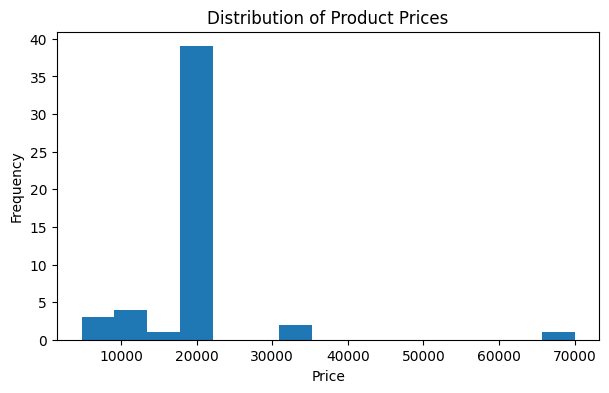

In [15]:
plt.figure(figsize=(7,4))

plt.hist(df["Prices"].dropna(), bins=15)

plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

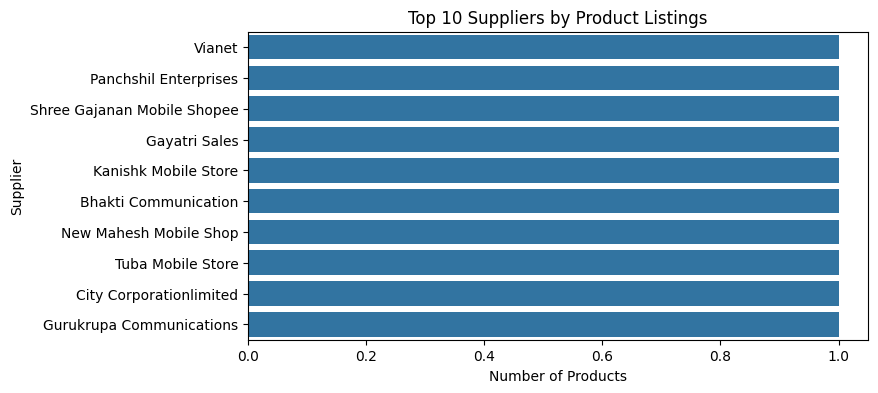

In [16]:
top_suppliers = df["Company Name"].value_counts().head(10)

plt.figure(figsize=(8,4))

sns.barplot(x=top_suppliers.values, y=top_suppliers.index)

plt.title("Top 10 Suppliers by Product Listings")
plt.xlabel("Number of Products")
plt.ylabel("Supplier")

plt.show()

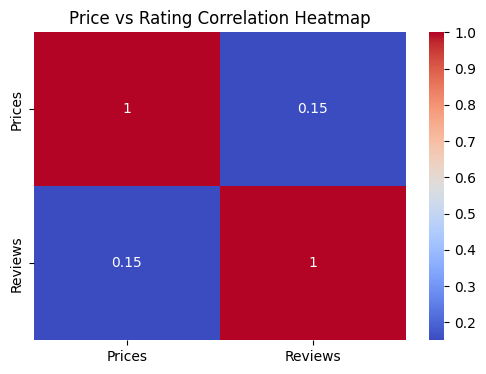

In [17]:
corr = df[["Prices","Reviews"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Price vs Rating Correlation Heatmap")

plt.show()

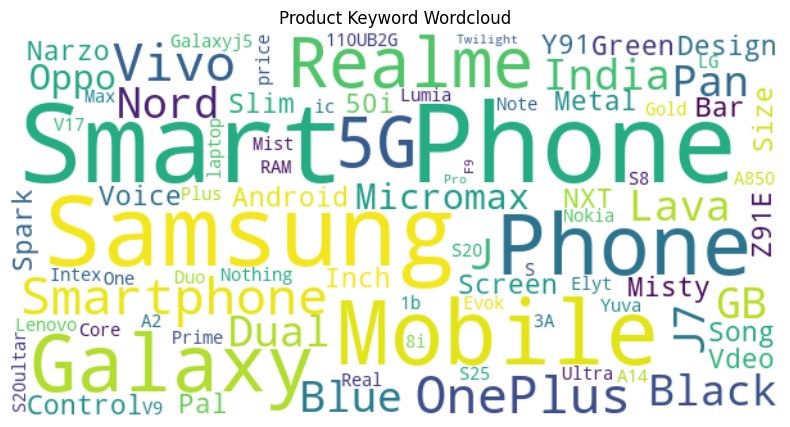

In [18]:
text = " ".join(df["Names"].dropna())

wordcloud = WordCloud(
    width=600,
    height=300,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")

plt.title("Product Keyword Wordcloud")

plt.show()

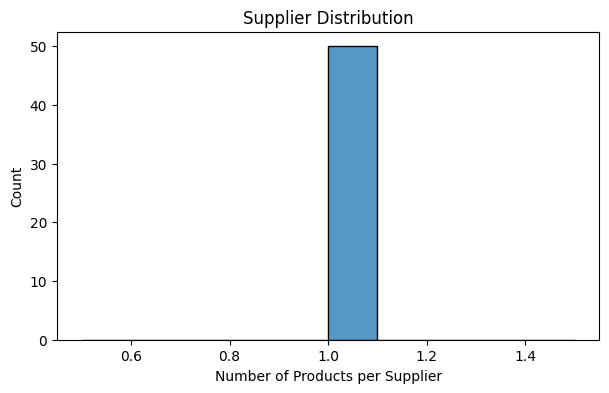

In [19]:
supplier_counts = df["Company Name"].value_counts()

plt.figure(figsize=(7,4))

sns.histplot(supplier_counts, bins=10)

plt.title("Supplier Distribution")
plt.xlabel("Number of Products per Supplier")

plt.show()

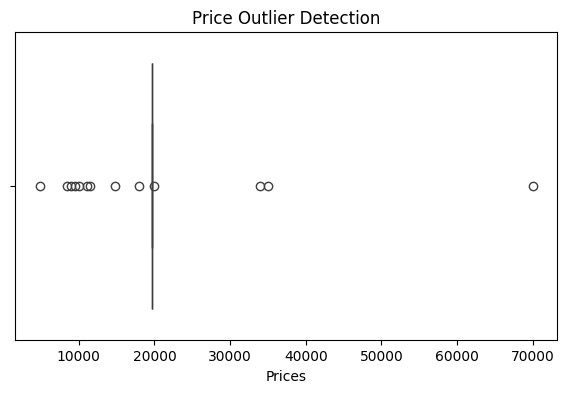

In [20]:
plt.figure(figsize=(7,4))

sns.boxplot(x=df["Prices"])

plt.title("Price Outlier Detection")

plt.show()

In [21]:
df.to_excel("eda_output.xlsx", index=False)